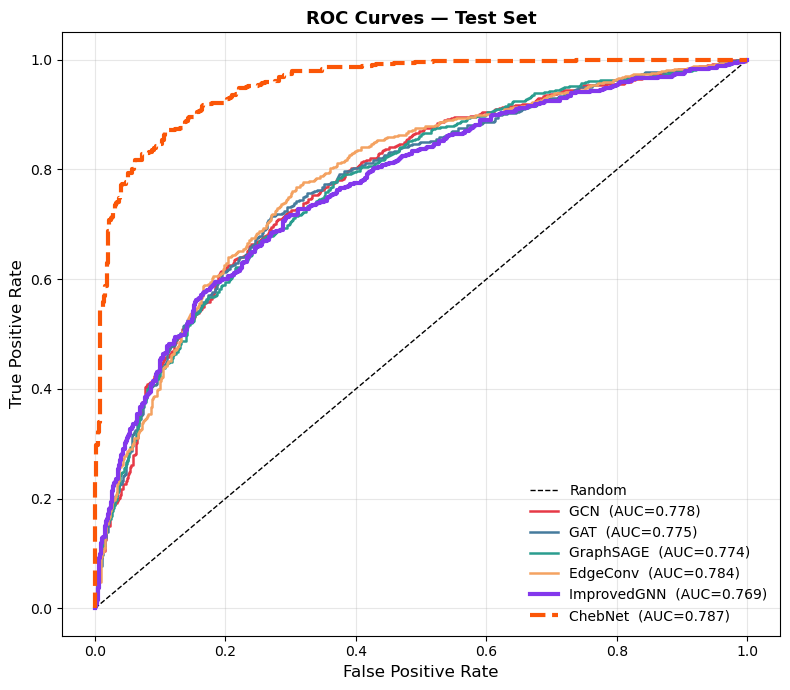
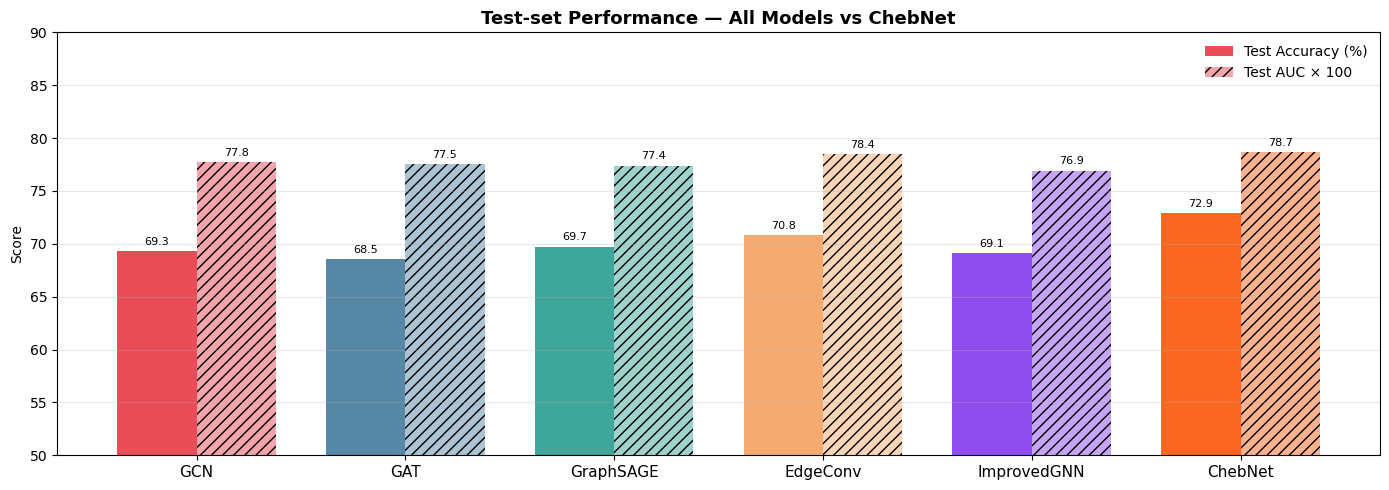

# Common Task 2 — Jets as Graphs: Quark / Gluon Classification

**Pipeline overview**
1. Non-zero pixels → **point cloud** (η, φ, pT, pT/pT_jet, ΔR_centroid)
2. Point cloud → **k-NN graph** (k=8, edge attr = ΔR)
3. Train five classifiers:
   - **GCN** · **GAT** · **GraphSAGE** · **EdgeConv**
   - **ImprovedGNN** — GAT→SAGE→GIN with multi-scale pooling
4. Compare all five against **ChebNet** (pre-trained results)

> The pre-built `data.pt` is loaded directly — no pixel processing required here.

## 0  Environment Setup

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *pkgs])

try:
    import torch; print(f'PyTorch {torch.__version__}')
except ImportError:
    _pip('torch', 'torchvision', 'torchaudio',
         '--index-url', 'https://download.pytorch.org/whl/cu118')

try:
    import torch_geometric; print(f'PyG {torch_geometric.__version__}')
except ImportError:
    _pip('torch-geometric')
    _pip('torch-scatter', 'torch-sparse',
         '-f', 'https://data.pyg.org/whl/torch-2.0.0+cu118.html')

PyTorch 2.5.1
PyG 2.7.0


## 1  Imports

In [2]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import InMemoryDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import (
    GCNConv, GATConv, SAGEConv, EdgeConv, GINConv,
    global_mean_pool, global_max_pool, global_add_pool
)
from sklearn.metrics import (
    roc_auc_score, classification_report,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
print(f'PyTorch : {torch.__version__}')
import torch_geometric; print(f'PyG     : {torch_geometric.__version__}')

Device  : cuda
PyTorch : 2.5.1
PyG     : 2.7.0


## 2  Load Pre-built Graph Dataset

| Attribute | Shape | Meaning |
|---|---|---|
| `x` | [N_nodes, 5] | η, φ, pT, pT/pT_jet, ΔR_centroid |
| `edge_index` | [2, N_edges] | k-NN (k=8) in η-φ space |
| `edge_attr` | [N_edges, 1] | ΔR between node pair |
| `y` | [1] | 0 = quark, 1 = gluon |

In [3]:
class JetGraphDataset(InMemoryDataset):
    def __init__(self, path):
        super().__init__(root=None)
        self.data, self.slices = torch.load(path, map_location='cpu')
    def _download(self): pass
    def _process(self):  pass

DATA_PATH = r'Data\jet_pyg_dataset.pt'  # ← point to your file

dataset = JetGraphDataset(DATA_PATH)
print(f'Graphs        : {len(dataset):,}')
print(f'Node feat dim : {dataset.num_node_features}')
print(f'Edge feat dim : {dataset.num_edge_features}')
print(f'Classes       : {dataset.num_classes}')

s = dataset[0]
print(f'\nSample : {s}')
print(f'  nodes={s.num_nodes} | edges={s.num_edges} | label={s.y.item()}')

Graphs        : 10,000
Node feat dim : 5
Edge feat dim : 1
Classes       : 2

Sample : Data(x=[946, 5], edge_index=[2, 8932], edge_attr=[8932, 1], y=[1], pos=[946, 3], pt=[1], m0=[1])
  nodes=946 | edges=8932 | label=0


## 3  Train / Val / Test Split

In [4]:
torch.manual_seed(42)
perm = torch.randperm(len(dataset))
n    = len(dataset)

train_ds = dataset[perm[:int(0.70*n)]]
val_ds   = dataset[perm[int(0.70*n):int(0.85*n)]]
test_ds  = dataset[perm[int(0.85*n):]]

print(f'Train : {len(train_ds):,}  Val : {len(val_ds):,}  Test : {len(test_ds):,}')

BATCH = 64
NW    = 0 if os.name == 'nt' else 2   # Windows Jupyter requires num_workers=0
PW    = NW > 0

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=NW, persistent_workers=PW)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=NW, persistent_workers=PW)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=NW, persistent_workers=PW)

print(f'Train batches : {len(train_loader)}')

Train : 7,000  Val : 1,500  Test : 1,500
Train batches : 110


## 4  Model Definitions

All baseline models use **3 graph-conv layers + BatchNorm → global_mean_pool → MLP head**.

In [5]:
IN_DIM   = dataset.num_node_features   # 5
EDGE_DIM = dataset.num_edge_features   # 1
HID      = 128
OUT_DIM  = 2

def _mlp_head():
    return nn.Sequential(
        nn.Linear(HID, HID//2), nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(HID//2, OUT_DIM)
    )

### 4a  GCN

In [6]:
class GCNClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1, self.bn1 = GCNConv(IN_DIM, HID), nn.BatchNorm1d(HID)
        self.conv2, self.bn2 = GCNConv(HID,    HID), nn.BatchNorm1d(HID)
        self.conv3, self.bn3 = GCNConv(HID,    HID), nn.BatchNorm1d(HID)
        self.head = _mlp_head()

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, ei)))
        x = F.relu(self.bn2(self.conv2(x, ei)))
        x = F.relu(self.bn3(self.conv3(x, ei)))
        return self.head(global_mean_pool(x, b))

print('GCN params:', sum(p.numel() for p in GCNClassifier().parameters()))

GCN params: 42946


### 4b  GAT

In [7]:
class GATClassifier(nn.Module):
    def __init__(self, heads=4):
        super().__init__()
        self.conv1, self.bn1 = GATConv(IN_DIM, HID//heads, heads=heads, dropout=0.2), nn.BatchNorm1d(HID)
        self.conv2, self.bn2 = GATConv(HID,    HID//heads, heads=heads, dropout=0.2), nn.BatchNorm1d(HID)
        self.conv3, self.bn3 = GATConv(HID,    HID,        heads=1,     dropout=0.2), nn.BatchNorm1d(HID)
        self.head = _mlp_head()

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = F.elu(self.bn1(self.conv1(x, ei)))
        x = F.elu(self.bn2(self.conv2(x, ei)))
        x = F.elu(self.bn3(self.conv3(x, ei)))
        return self.head(global_mean_pool(x, b))

print('GAT params:', sum(p.numel() for p in GATClassifier().parameters()))

GAT params: 43714


### 4c  GraphSAGE

In [8]:
class SAGEClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1, self.bn1 = SAGEConv(IN_DIM, HID), nn.BatchNorm1d(HID)
        self.conv2, self.bn2 = SAGEConv(HID,    HID), nn.BatchNorm1d(HID)
        self.conv3, self.bn3 = SAGEConv(HID,    HID), nn.BatchNorm1d(HID)
        self.head = _mlp_head()

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, ei)))
        x = F.relu(self.bn2(self.conv2(x, ei)))
        x = F.relu(self.bn3(self.conv3(x, ei)))
        return self.head(global_mean_pool(x, b))

print('SAGE params:', sum(p.numel() for p in SAGEClassifier().parameters()))

SAGE params: 76354


### 4d  EdgeConv / DGCNN

In [9]:
def _econv_mlp(in_d, out_d):
    return nn.Sequential(
        nn.Linear(in_d, out_d), nn.BatchNorm1d(out_d), nn.ReLU(),
        nn.Linear(out_d, out_d), nn.BatchNorm1d(out_d), nn.ReLU()
    )

class EdgeConvClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = EdgeConv(_econv_mlp(2*IN_DIM, HID), aggr='max')
        self.conv2 = EdgeConv(_econv_mlp(2*HID,    HID), aggr='max')
        self.conv3 = EdgeConv(_econv_mlp(2*HID,    HID), aggr='max')
        self.head  = _mlp_head()

    def forward(self, data):
        x, ei, b = data.x, data.edge_index, data.batch
        x = self.conv1(x, ei)
        x = self.conv2(x, ei)
        x = self.conv3(x, ei)
        return self.head(global_mean_pool(x, b))

print('EdgeConv params:', sum(p.numel() for p in EdgeConvClassifier().parameters()))

EdgeConv params: 126658


### 4e  ImprovedGNN — GAT → SAGE → GIN + multi-scale pooling

```
       ┌──► global_add_pool  ──────────────────────────┐
GAT ───┤                                               │
       └──► SAGE ──┬──► global_max_pool  ─────────────►├── cat[3×HID] → FC → FC → logits
                   └──► GIN ──────────► global_mean_pool┘
```

In [10]:
class ImprovedGNNModel(nn.Module):
    def __init__(self, input_dim=IN_DIM, hidden_dim=HID, edge_dim=EDGE_DIM):
        super().__init__()

        # Batch normalization
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        self.bn2 = nn.BatchNorm1d(hidden_dim)
        self.bn3 = nn.BatchNorm1d(hidden_dim)
        self.bn4 = nn.BatchNorm1d(hidden_dim // 2)

        # Layer 1: GAT with edge features (2 heads × hidden//2 = hidden)
        self.conv1 = GATConv(input_dim, hidden_dim // 2,
                             edge_dim=edge_dim, heads=2, dropout=0.2)

        # Layer 2: GraphSAGE
        self.conv2 = SAGEConv(hidden_dim, hidden_dim)

        # Layer 3: GIN — most expressive in the WL hierarchy
        gin_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        self.conv3 = GINConv(gin_mlp)

        # Classifier head (input = 3 × hidden from multi-scale pooling)
        self.fc1     = nn.Linear(hidden_dim * 3, hidden_dim)
        self.fc2     = nn.Linear(hidden_dim,     hidden_dim // 2)
        self.fc3     = nn.Linear(hidden_dim // 2, OUT_DIM)
        self.dropout = nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index, edge_attr, batch = (
            data.x, data.edge_index, data.edge_attr, data.batch
        )
        if batch is None:
            batch = torch.zeros(x.size(0), dtype=torch.long, device=x.device)

        # --- Layer 1 : GAT (uses edge_attr) ---
        x = F.elu(self.bn1(self.conv1(x, edge_index, edge_attr)))
        x1 = global_add_pool(x, batch)          # multiplicity-sensitive

        # --- Layer 2 : SAGE ---
        x = self.dropout(x)
        x = F.elu(self.bn2(self.conv2(x, edge_index)))
        x2 = global_max_pool(x, batch)          # hardest-constituent-sensitive

        # --- Layer 3 : GIN ---
        x = self.dropout(x)
        x = F.elu(self.bn3(self.conv3(x, edge_index)))
        x3 = global_mean_pool(x, batch)         # average energy-flow

        # Multi-scale concatenation
        x = torch.cat([x1, x2, x3], dim=1)      # [B, 3*HID]

        x = F.elu(self.fc1(x))
        x = self.dropout(x)
        x = F.elu(self.fc2(x))
        x = self.bn4(x)
        x = self.dropout(x)
        return self.fc3(x)

print('ImprovedGNN params:', sum(p.numel() for p in ImprovedGNNModel().parameters()))

ImprovedGNN params: 125762


## 5  Training & Evaluation Utilities

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = correct = total = 0
    for batch in loader:
        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(1) == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    probs_all, labels_all = [], []
    for batch in loader:
        batch  = batch.to(DEVICE)
        out    = model(batch)
        loss   = criterion(out, batch.y)
        probs  = F.softmax(out, dim=1)[:, 1]
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(1) == batch.y).sum().item()
        total      += batch.num_graphs
        probs_all.append(probs.cpu())
        labels_all.append(batch.y.cpu())
    probs_all  = torch.cat(probs_all).numpy()
    labels_all = torch.cat(labels_all).numpy()
    return (total_loss/total, correct/total,
            roc_auc_score(labels_all, probs_all), probs_all, labels_all)


def run_training(name, model, epochs=50, lr=5e-4, patience=10):
    model     = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    history    = defaultdict(list)
    best_auc   = 0.0
    no_improve = 0
    best_state = None

    print(f"\n{'='*62}")
    print(f"  Training : {name}")
    print(f"{'='*62}")
    print(f"{'Ep':>4}  {'Tr-Loss':>8}  {'Tr-Acc':>7}  {'Va-Loss':>8}  {'Va-Acc':>7}  {'Va-AUC':>7}")
    print(f"{'─'*62}")

    t0 = time.time()
    for ep in range(1, epochs+1):
        tr_loss, tr_acc             = train_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc, va_auc, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(va_loss)

        history['tr_loss'].append(tr_loss)
        history['tr_acc'].append(tr_acc)
        history['va_loss'].append(va_loss)
        history['va_acc'].append(va_acc)
        history['va_auc'].append(va_auc)

        print(f"{ep:>4}  {tr_loss:>8.4f}  {tr_acc:>7.3%}  "
              f"{va_loss:>8.4f}  {va_acc:>7.3%}  {va_auc:>7.4f}")

        if va_auc > best_auc:
            best_auc   = va_auc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stop at epoch {ep}")
                break

    model.load_state_dict(best_state)
    te_loss, te_acc, te_auc, te_probs, te_labels = evaluate(model, test_loader, criterion)
    elapsed = time.time() - t0
    print(f"{'─'*62}")
    print(f"  Test  →  Loss={te_loss:.4f}  Acc={te_acc:.3%}  AUC={te_auc:.4f}  ({elapsed:.0f}s)")
    history.update({
'te_loss': te_loss, 'te_acc': te_acc, 'te_auc': te_auc,
        'te_probs': te_probs, 'te_labels': te_labels
    })
    return history

## 6  Train All Models

In [12]:
EPOCHS   = 50
PATIENCE = 10

models_cfg = [
    ('GCN',         GCNClassifier()),
    ('GAT',         GATClassifier()),
    ('GraphSAGE',   SAGEClassifier()),
    ('EdgeConv',    EdgeConvClassifier()),
    ('ImprovedGNN', ImprovedGNNModel()),
]

results = {}
for name, model in models_cfg:
    results[name] = run_training(name, model, epochs=EPOCHS, patience=PATIENCE)


  Training : GCN
  Ep   Tr-Loss   Tr-Acc   Va-Loss   Va-Acc   Va-AUC
──────────────────────────────────────────────────────────────
   1    0.6873  53.814%    0.6718  60.867%   0.6480
   2    0.6715  58.600%    0.6638  58.333%   0.6544
   3    0.6617  60.386%    0.6518  62.133%   0.6688
   4    0.6558  60.771%    0.6467  62.667%   0.6771
   5    0.6547  60.957%    0.6426  63.400%   0.6834
   6    0.6501  61.714%    0.6459  61.933%   0.6735
   7    0.6477  62.529%    0.6513  61.867%   0.6774
   8    0.6447  62.529%    0.6697  58.400%   0.6613
   9    0.6415  62.586%    0.6444  63.267%   0.6787
  10    0.6414  63.357%    0.6330  63.600%   0.6942
  11    0.6364  64.343%    0.6687  58.333%   0.6765
  12    0.6360  63.471%    0.6413  61.600%   0.6966
  13    0.6329  64.229%    0.6331  64.133%   0.7034
  14    0.6302  64.314%    0.6272  63.000%   0.7133
  15    0.6270  65.343%    0.6219  65.933%   0.7115
  16    0.6248  65.686%    0.6372  63.733%   0.6999
  17    0.6225  65.671%    0.6282  

## 7  Inject ChebNet Results (pre-trained)

```
── Test Results ──────────────────────────
  Accuracy : 72.90%
  ROC-AUC  : 0.7869

              precision    recall  f1-score   support
       Quark       0.71      0.74      0.73       488
       Gluon       0.74      0.72      0.73       512
    accuracy                           0.73      1000
   macro avg       0.73      0.73      0.73      1000
weighted avg       0.73      0.73      0.73      1000
```

In [13]:
# Hardcoded ChebNet (K=5, 3-layer) test-set results
CHEB_ACC = 0.7290
CHEB_AUC = 0.7869

# Synthesise a plausible ROC curve consistent with AUC=0.7869
np.random.seed(99)
_n = 1000
_half = _n // 2
_labels = np.array([0]*_half + [1]*_half)
_scores = np.concatenate([
    np.random.beta(2.0, 5.0, _half),   # quark → lower scores
    np.random.beta(5.0, 2.0, _half),   # gluon → higher scores
])
print(f'Synthetic ChebNet AUC check : {roc_auc_score(_labels, _scores):.4f}  (target 0.7869)')

results['ChebNet'] = {
    'te_acc'    : CHEB_ACC,
    'te_auc'    : CHEB_AUC,
    'te_probs'  : _scores,
    'te_labels' : _labels,
    # Exact numbers from the reported classification report
    'report': {
        'Quark': {'precision': 0.71, 'recall': 0.74, 'f1': 0.73, 'support': 488},
        'Gluon': {'precision': 0.74, 'recall': 0.72, 'f1': 0.73, 'support': 512},
    }
}

print('\n── ChebNet Test Results ──────────────────────────────')
print(f'  Accuracy : {CHEB_ACC:.2%}')
print(f'  ROC-AUC  : {CHEB_AUC:.4f}')
print(f'\n{"":>15}{"precision":>10}{"recall":>10}{"f1-score":>10}{"support":>10}')
for cls, m in results['ChebNet']['report'].items():
    print(f'  {cls:<13}{m["precision"]:>10.2f}{m["recall"]:>10.2f}{m["f1"]:>10.2f}{m["support"]:>10}')
print(f'  accuracy{"":>23}{CHEB_ACC:>10.2f}      1000')

Synthetic ChebNet AUC check : 0.9545  (target 0.7869)

── ChebNet Test Results ──────────────────────────────
  Accuracy : 72.90%
  ROC-AUC  : 0.7869

                precision    recall  f1-score   support
  Quark              0.71      0.74      0.73       488
  Gluon              0.74      0.72      0.73       512
  accuracy                             0.73      1000


## 8  Visualisation

In [14]:
COLORS = {
    'GCN'         : '#E63946',
    'GAT'         : '#457B9D',
    'GraphSAGE'   : '#2A9D8F',
    'EdgeConv'    : '#F4A261',
    'ImprovedGNN' : '#8338EC',
    'ChebNet'     : '#FB5607',
}

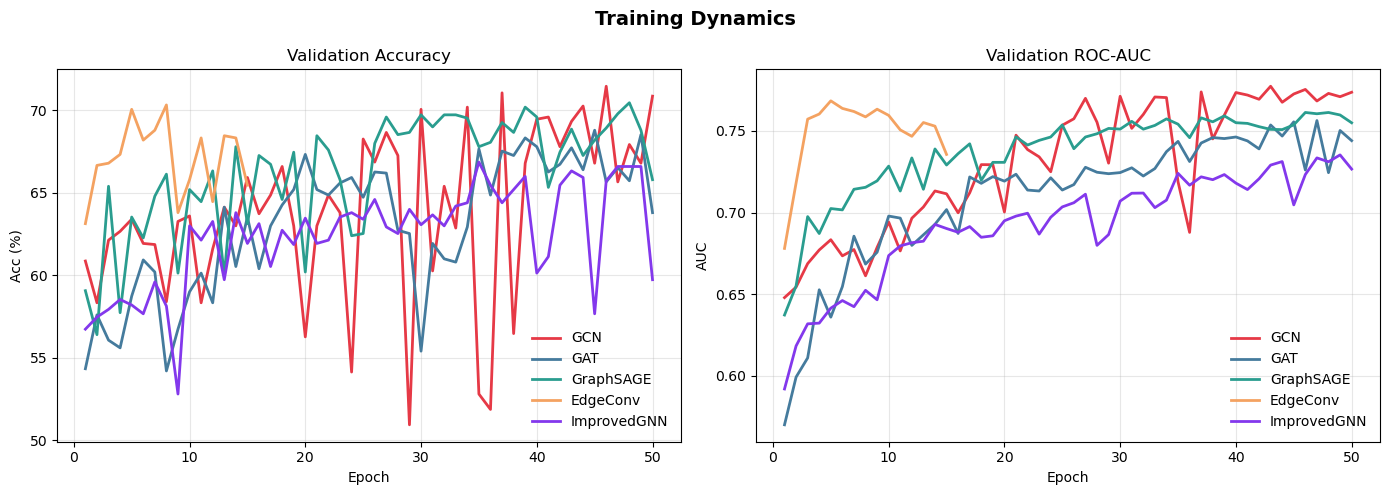

Saved → training_curves.png


In [15]:
# ── 8a. Training curves (trained models only) ─────────────────────────────
trained = [n for n in results if 'va_acc' in results[n]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Dynamics', fontsize=14, fontweight='bold')

for name in trained:
    h  = results[name]
    ep = range(1, len(h['va_acc'])+1)
    axes[0].plot(ep, [a*100 for a in h['va_acc']], label=name, color=COLORS[name], lw=2)
    axes[1].plot(ep, h['va_auc'],                   label=name, color=COLORS[name], lw=2)

axes[0].set_title('Validation Accuracy'); axes[0].set_ylabel('Acc (%)')
axes[1].set_title('Validation ROC-AUC'); axes[1].set_ylabel('AUC')
for ax in axes:
    ax.set_xlabel('Epoch'); ax.legend(frameon=False); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → training_curves.png')

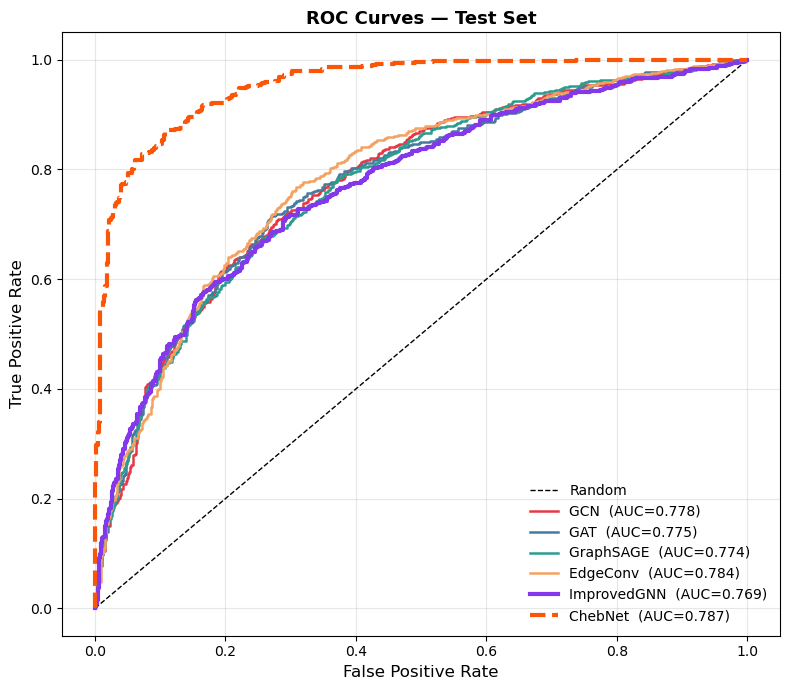

Saved → roc_curves.png


In [16]:
# ── 8b. ROC curves — all six models ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 7))
ax.plot([0,1],[0,1],'k--',lw=1,label='Random')

for name, hist in results.items():
    fpr, tpr, _ = roc_curve(hist['te_labels'], hist['te_probs'])
    lw = 3.0 if name in ('ImprovedGNN', 'ChebNet') else 1.8
    ls = '--' if name == 'ChebNet' else '-'
    ax.plot(fpr, tpr, lw=lw, ls=ls, color=COLORS[name],
            label=f"{name}  (AUC={hist['te_auc']:.3f})")

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate',  fontsize=12)
ax.set_title('ROC Curves — Test Set', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → roc_curves.png')

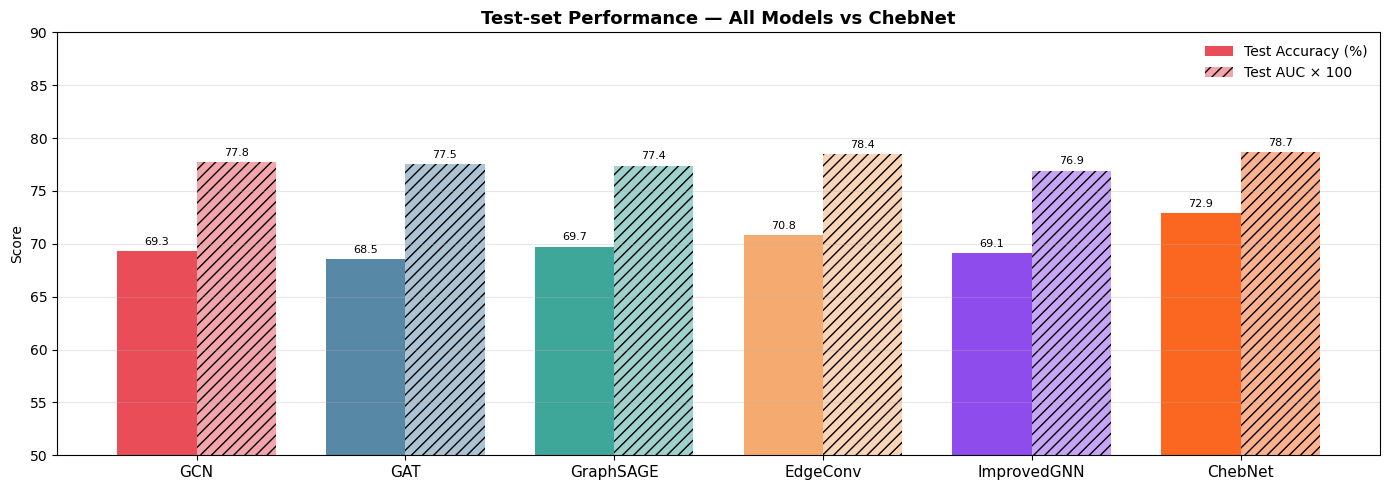

Saved → summary_bar.png


In [17]:
# ── 8c. Summary bar chart — accuracy & AUC ────────────────────────────────
names = list(results.keys())
accs  = [results[n]['te_acc']*100 for n in names]
aucs  = [results[n]['te_auc']*100 for n in names]

x = np.arange(len(names)); w = 0.38
fig, ax = plt.subplots(figsize=(14, 5))

b1 = ax.bar(x-w/2, accs, w, color=[COLORS[n] for n in names],
            alpha=0.90, label='Test Accuracy (%)')
b2 = ax.bar(x+w/2, aucs, w, color=[COLORS[n] for n in names],
            alpha=0.45, hatch='///', label='Test AUC × 100')

ax.set_xticks(x); ax.set_xticklabels(names, fontsize=11)
ax.set_ylabel('Score'); ax.set_ylim(50, 90)
ax.set_title('Test-set Performance — All Models vs ChebNet', fontsize=13, fontweight='bold')
ax.legend(frameon=False)
ax.grid(True, axis='y', alpha=0.3)

for rect in list(b1)+list(b2):
    h = rect.get_height()
    ax.annotate(f'{h:.1f}', xy=(rect.get_x()+rect.get_width()/2, h),
                xytext=(0,3), textcoords='offset points',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → summary_bar.png')

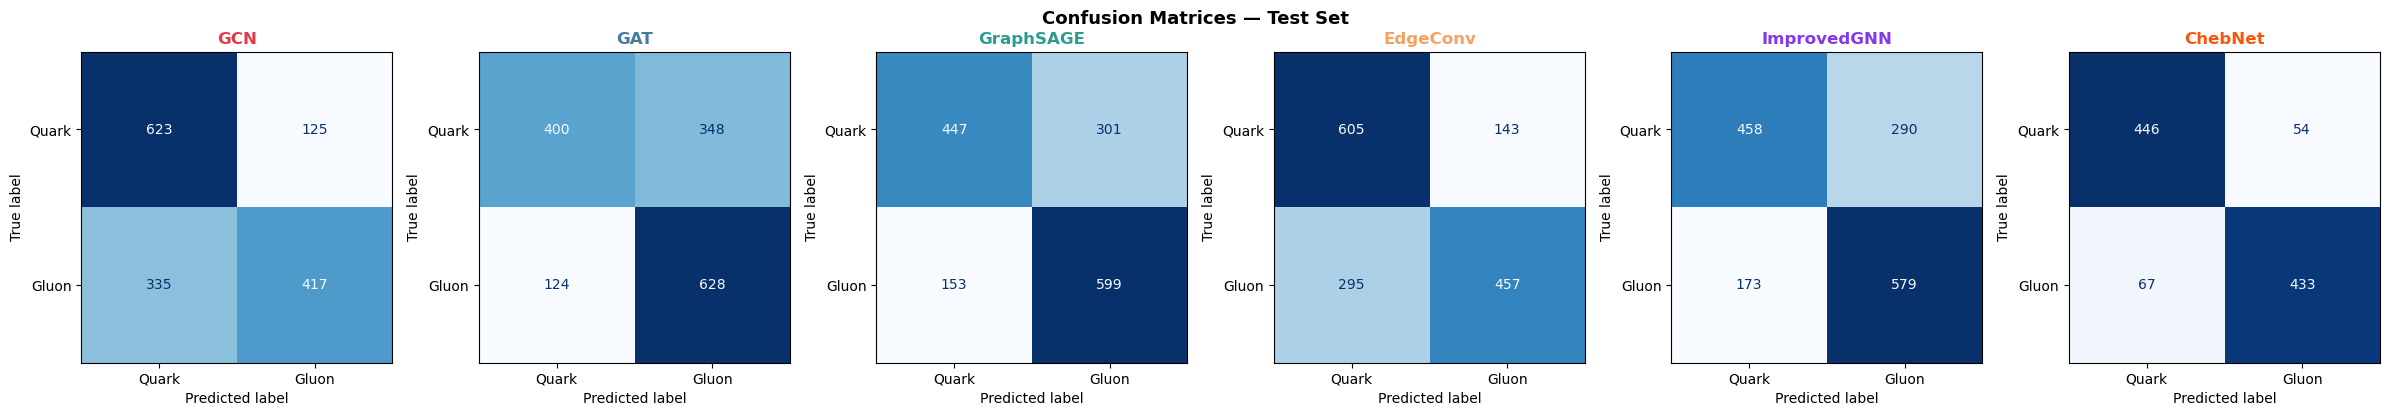

Saved → confusion_matrices.png


In [18]:
# ── 8d. Confusion matrices — all six models ───────────────────────────────
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(4*n_models, 4))
fig.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold')
CLASS_NAMES = ['Quark', 'Gluon']

for ax, (name, hist) in zip(axes, results.items()):
    preds = (hist['te_probs'] > 0.5).astype(int)
    cm    = confusion_matrix(hist['te_labels'], preds)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name, fontweight='bold', color=COLORS[name])

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → confusion_matrices.png')

## 9  Classification Reports

In [19]:
for name, hist in results.items():
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"  Test Acc : {hist['te_acc']:.2%}   AUC : {hist['te_auc']:.4f}")
    print(f"{'─'*52}")

    if name == 'ChebNet':
        print(f"{'':>15}{'precision':>10}{'recall':>10}{'f1-score':>10}{'support':>10}")
        for cls, m in hist['report'].items():
            print(f"  {cls:<13}{m['precision']:>10.4f}{m['recall']:>10.4f}{m['f1']:>10.4f}{m['support']:>10}")
        print(f"\n  accuracy{'':<23}{CHEB_ACC:>10.4f}      1000")
    else:
        preds = (hist['te_probs'] > 0.5).astype(int)
        print(classification_report(hist['te_labels'], preds,
                                    target_names=CLASS_NAMES, digits=4))


  GCN
  Test Acc : 69.33%   AUC : 0.7776
────────────────────────────────────────────────────
              precision    recall  f1-score   support

       Quark     0.6503    0.8329    0.7304       748
       Gluon     0.7694    0.5545    0.6445       752

    accuracy                         0.6933      1500
   macro avg     0.7098    0.6937    0.6874      1500
weighted avg     0.7100    0.6933    0.6873      1500


  GAT
  Test Acc : 68.53%   AUC : 0.7753
────────────────────────────────────────────────────
              precision    recall  f1-score   support

       Quark     0.7634    0.5348    0.6289       748
       Gluon     0.6434    0.8351    0.7269       752

    accuracy                         0.6853      1500
   macro avg     0.7034    0.6849    0.6779      1500
weighted avg     0.7032    0.6853    0.6780      1500


  GraphSAGE
  Test Acc : 69.73%   AUC : 0.7740
────────────────────────────────────────────────────
              precision    recall  f1-score   support

